# Stock Analysis using ML

In [1]:
# import piplite
# await piplite.install(['pandas'])
# await piplite.install(['numpy'])
# await piplite.install(['seaborn'])
# await piplite.install(['pandas_ta'])
# await piplite.install(['yfinance'])
# await piplite.install(['pandas_datareader'])
# await piplite.install(['sklearn'])
# await piplite.install(['matplotlib'])
# await piplite.install(['plotly'])
# await piplite.install(['nltk'])
# await piplite.install(['textblob'])
# await piplite.install(['vaderSentiment'])
# await piplite.install(['transformers'])
# await piplite.install(['scipy'])
# await piplite.install(['statsmodels'])
# await piplite.install(['fredapi'])

In [2]:
import re
import pytz
import nltk
import wbdata
import textblob 
import numpy as np
import pandas as pd
import seaborn as sns
import vaderSentiment
import yfinance as yf
import pandas_ta as ta
from fredapi import Fred
import statsmodels.api as sm
from pandas_ta import Imports
from textblob import TextBlob
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from transformers import pipeline
import pandas_datareader as pdr
import pandas_datareader.data as web
from sklearn.metrics import precision_score
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from datetime import date, datetime, timedelta
from pandas.plotting import autocorrelation_plot
from dateutil.relativedelta import relativedelta
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from statsmodels.tsa.stattools import grangercausalitytests
from sklearn.metrics import mean_squared_error, mean_absolute_error
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [3]:
prevDate = (date.today() - timedelta(1)).strftime('%Y-%m-%d')
currDate = (date.today()).strftime('%Y-%m-%d')
endDate = (date.today() + timedelta(3)).strftime('%Y-%m-%d')

tenYrDate = (datetime.strptime(currDate, '%Y-%m-%d').now() -
               relativedelta(years=10)).strftime('%Y-%m-%d')
_52WeeksDate = (datetime.strptime(currDate, '%Y-%m-%d').now() -
               relativedelta(weeks=52)).strftime('%Y-%m-%d')

updateDT = (date.today()).strftime('%Y-%m-%d %H:%M:%S+0530')
prevDT = (date.today() - timedelta(1)).strftime('%Y-%m-%d %H:%M:%S+0530')
endDT = (date.today() + timedelta(3)).strftime('%Y-%m-%d %H:%M:%S+0530')

print(prevDate, currDate, endDate, tenYrDate, _52WeeksDate, updateDT, prevDT, endDT)

2025-01-06 2025-01-07 2025-01-10 2015-01-07 2024-01-09 2025-01-07 00:00:00+0530 2025-01-06 00:00:00+0530 2025-01-10 00:00:00+0530


In [4]:
wdf = pd.read_csv('Trading_Holidays.csv')
tradingHolidays = wdf['Week']
weekHolidays = ['Sunday', 'Saturday']
tradeWeekHolidays = pd.concat([tradingHolidays, pd.Series(weekHolidays)], ignore_index=True)

In [5]:
tickersListName = "20MICRONS.NS"
stockTicker = yf.Ticker(tickersListName)
tickHistory = stockTicker.history(period="max")

In [6]:
# Fetch and print industry and sector information
sector = stockTicker.info.get('sector')
industry = stockTicker.info.get('industry')
companyName = stockTicker.info.get('longName', 'N/A')
tickerSymbol = tickersListName.replace(".NS", "")
startDate = tickHistory.index.min()

print("Start Date: ", startDate)
print("Symbol: ", tickerSymbol)
print("Company Name:", companyName)
print("Sector:", sector)
print("Industry:", industry)

Start Date:  2008-10-06 00:00:00+05:30
Symbol:  20MICRONS
Company Name: 20 Microns Limited
Sector: Basic Materials
Industry: Other Industrial Metals & Mining


### Fundamental Analysis

In [7]:
financials = stockTicker.financials  # Get financial statements
balance_sheet = stockTicker.balance_sheet  # Get balance sheet
cashflow = stockTicker.cashflow  # Get cash flow statements

# Display the financial data
print(financials)
# print(balance_sheet)
# print(cashflow)

                                                          2024-03-31  \
Tax Effect Of Unusual Items                          -2519447.229262   
Tax Rate For Calcs                                          0.270501   
Normalized EBITDA                                       1004260000.0   
Total Unusual Items                                       -9314000.0   
Total Unusual Items Excluding Goodwill                    -9314000.0   
Net Income From Continuing Operation Net Minori...       560698000.0   
Reconciled Depreciation                                  143492000.0   
Reconciled Cost Of Revenue                              4991028000.0   
EBITDA                                                   994946000.0   
EBIT                                                     851454000.0   
Net Interest Income                                     -154128000.0   
Interest Expense                                          81605000.0   
Interest Income                                           104930

In [8]:
# print(round(tickHistory,2))
tickHistory

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2008-10-06 00:00:00+05:30,34.939769,34.939769,13.801209,14.652865,23501600,0.0,0.0
2008-10-07 00:00:00+05:30,13.975907,16.596389,12.163406,13.124249,9113400,0.0,0.0
2008-10-08 00:00:00+05:30,12.228919,12.753016,10.962352,11.573798,2464384,0.0,0.0
2008-10-10 00:00:00+05:30,10.875002,10.875002,9.455574,10.132532,1207928,0.0,0.0
2008-10-13 00:00:00+05:30,10.612954,11.617473,10.176207,10.765816,898692,0.0,0.0
...,...,...,...,...,...,...,...
2025-01-01 00:00:00+05:30,235.479996,239.449997,232.050003,236.809998,38786,0.0,0.0
2025-01-02 00:00:00+05:30,239.399994,248.649994,236.119995,248.649994,82081,0.0,0.0
2025-01-03 00:00:00+05:30,255.899994,261.079987,248.500000,261.029999,102182,0.0,0.0


In [9]:
# Get stock price
price = stockTicker.history(period="1d")['Close'].iloc[0]

# Get Earnings Per Share (EPS)
eps = stockTicker.info['trailingEps']

# Calculate P/E Ratio
pe_ratio = price / eps
print(f"P/E Ratio: {pe_ratio}")

# Get book value per share
book_value_per_share = stockTicker.info['bookValue']

# Calculate P/B Ratio
pb_ratio = price / book_value_per_share
print(f"P/B Ratio: {pb_ratio}")

# Balance Sheet Labels
liabilities_label = balance_sheet.index[balance_sheet.index.str.contains("Total Liabilities", case=False, na=False)]
equity_label = balance_sheet.index[balance_sheet.index.str.contains("Stockholders Equity", case=False, na=False)]

# Get total liabilities and shareholders' equity
total_liabilities = balance_sheet.loc[liabilities_label[0]].dropna().iloc[0]  # balance_sheet.loc['Total Liabilities'][0]
shareholder_equity = balance_sheet.loc[equity_label[0]].dropna().iloc[0]  # balance_sheet.loc['Total Stockholder Equity'][0]

# Calculate Debt-to-Equity Ratio
de_ratio = total_liabilities / shareholder_equity
print(f"Debt-to-Equity Ratio: {de_ratio}")


P/E Ratio: 15.08313539192399
P/B Ratio: 2.336319652679409
Debt-to-Equity Ratio: 0.667793537792634


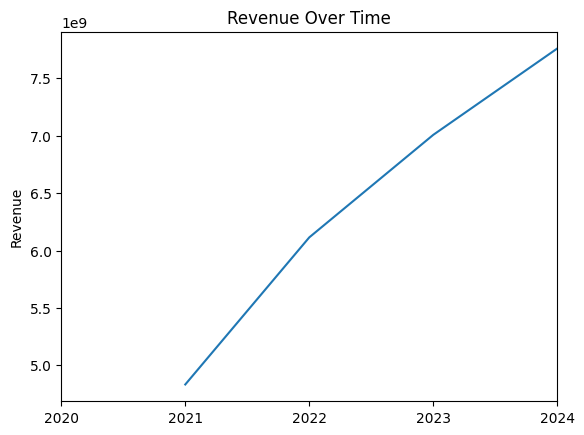

In [10]:
# Plot revenue over time
revenue = financials.loc['Total Revenue']
revenue.plot(kind='line')
plt.title("Revenue Over Time")
plt.ylabel("Revenue")
plt.show()

In [11]:
# Competitor Companies
cdf = pd.read_csv("Stocks_Lists_NSE.csv")
competitorStocksDict = {}
competitors = cdf[(cdf["Sectors"] == sector) & (cdf["Industry"] == industry)]

for i in range(len(competitors)):
    if competitors.iloc[i]["Company_Names"] != companyName:
        competitorStocksDict[competitors.iloc[i]["Symbols"]] = [competitors.iloc[i]["Company_Names"], competitors.iloc[i]["Short_Names"]]
print(competitorStocksDict)

{'ASHAPURMIN': ['Ashapura Minechem Limited', 'AsMiLi']}


In [12]:
# Download data for competitor companies
compet_pe_ratio = 0
sym_compet = ""
for symbol, cNames in competitorStocksDict.items():    
    sym_compet = symbol
    stock_compet = yf.Ticker(symbol+".NS")
    compet_pe_ratio = stock_compet.info['trailingPE']
    print(f"{companyName} P/E Ratio: {pe_ratio}")
    print(f"{cNames[0]} P/E Ratio: {compet_pe_ratio}")

20 Microns Limited P/E Ratio: 15.08313539192399
Ashapura Minechem Limited P/E Ratio: 18.076448


In [13]:
# Calculate revenue growth (year over year)
revenue_growth = (revenue.iloc[0] - revenue.iloc[1]) / revenue.iloc[1] * 100
print(f"Revenue Growth YoY: {revenue_growth}%")


Revenue Growth YoY: 10.734717723510688%


In [14]:
stocks = [kSym for kSym, vals in competitorStocksDict.items()]
data = {}
for stock_symbol in stocks:
    stock_compt = yf.Ticker(stock_symbol+".NS")
    price_compt = stock_compt.history(period="1d")['Close'].iloc[0]
    eps_compt = stock_compt.info['trailingEps']
    pe_ratio_compt = price_compt / eps_compt if eps_compt > 0 else 'N/A'
    print(f"{stock_symbol} P/E Ratio: {pe_ratio_compt}")
    data = {'Stock': [tickerSymbol, stock_symbol], 'P/E Ratio': [pe_ratio_compt, compet_pe_ratio]}

ASHAPURMIN P/E Ratio: 18.076448326879113


In [15]:
# Create a dataframe with the analysis results
    # data = {'Stock': stock_symbol, 'P/E Ratio': pe_ratio}

df = pd.DataFrame(data)
df.to_csv('stock_analysis.csv', index=False)
# print(data)

### Technical Analysis

In [16]:
# Download stock data (e.g., Apple)
stock_data = yf.download(tickersListName, start=_52WeeksDate, end=endDate)

# Display the first few rows of the data
# print(stock_data.head())
stock_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,20MICRONS.NS,20MICRONS.NS,20MICRONS.NS,20MICRONS.NS,20MICRONS.NS,20MICRONS.NS
Date,,,,,,
2024-01-09 00:00:00+00:00,174.210617,175.199997,179.949997,172.350006,177.050003,158254
2024-01-10 00:00:00+00:00,174.061462,175.050003,176.949997,173.449997,175.199997,68214
2024-01-11 00:00:00+00:00,176.746216,177.750000,179.300003,175.100006,178.000000,114645
2024-01-12 00:00:00+00:00,177.143951,178.149994,181.850006,177.000000,179.899994,144150
2024-01-15 00:00:00+00:00,175.652420,176.649994,183.000000,175.250000,181.649994,136183


In [17]:
# Calculate 50-day and 200-day Simple Moving Average (SMA)
stock_data['SMA_50'] = stock_data['Close'].rolling(window=50).mean()
stock_data['SMA_200'] = stock_data['Close'].rolling(window=200).mean()

# Calculate Exponential Moving Average (EMA)
stock_data['EMA_50'] = stock_data['Close'].ewm(span=50, adjust=False).mean()

print(stock_data[['SMA_50', 'SMA_200', 'EMA_50']].tail())


Price                        SMA_50    SMA_200      EMA_50
Ticker                                                    
Date                                                      
2025-01-01 00:00:00+00:00  249.4766  231.70585  248.978699
2025-01-02 00:00:00+00:00  248.1946  232.22560  248.965808
2025-01-03 00:00:00+00:00  247.2852  232.80775  249.438914
2025-01-06 00:00:00+00:00  246.2366  233.36210  249.381310
2025-01-07 00:00:00+00:00  245.4286  233.89010  249.562435


In [18]:
# Calculate 14-period RSI
stock_data['RSI'] = ta.rsi(stock_data['Close'], length=14)

print(stock_data[['RSI']].tail())

Price                       RSI
Ticker                         
Date                           
2025-01-01 00:00:00+00:00  None
2025-01-02 00:00:00+00:00  None
2025-01-03 00:00:00+00:00  None
2025-01-06 00:00:00+00:00  None
2025-01-07 00:00:00+00:00  None


In [19]:
# Calculate MACD
# macd = ta.macd(close='Close', fast=12, slow=26, signal=9)

# Get the 26-day EMA of the closing price
k = stock_data['Close'].ewm(span=12, adjust=False, min_periods=12).mean()
# Get the 12-day EMA of the closing price
d = stock_data['Close'].ewm(span=26, adjust=False, min_periods=26).mean()
# Subtract the 26-day EMA from the 12-Day EMA to get the MACD
macd = k - d

# The pandas_ta MACD function returns a DataFrame with MACD, Signal, and Histogram columns
if macd is not None:
    # Get the 9-Day EMA of the MACD for the Trigger line
    macd_s = macd.ewm(span=9, adjust=False, min_periods=9).mean()
    
    # Calculate the difference between the MACD - Trigger for the Convergence/Divergence value
    macd_h = macd - macd_s

    # Add all of our new values for the MACD to the dataframe
    stock_data['MACD'] = macd
    stock_data['Histogram'] = macd_h
    stock_data['Signal'] = macd_s
    
    print(stock_data[['MACD', 'Signal']].tail())
else:
    print("MACD calculation returned None. Check data or library installation.")


Price                          MACD    Signal
Ticker                                       
Date                                         
2025-01-01 00:00:00+00:00 -4.414341 -4.106523
2025-01-02 00:00:00+00:00 -3.148920 -3.915003
2025-01-03 00:00:00+00:00 -1.134029 -3.358808
2025-01-06 00:00:00+00:00 -0.584311 -2.803909
2025-01-07 00:00:00+00:00  0.334064 -2.176314


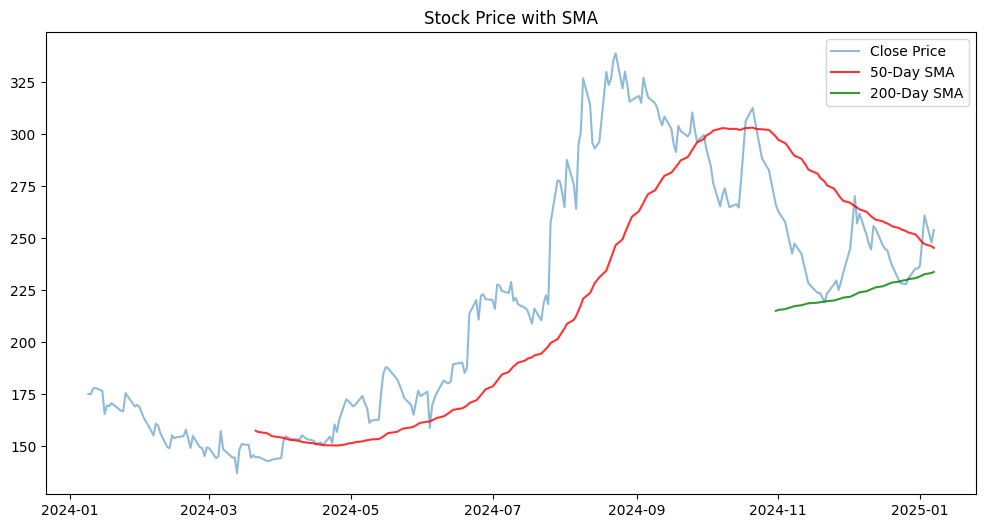

In [20]:
# Plot Closing price, 50-day SMA, and 200-day SMA
plt.figure(figsize=(12, 6))
plt.plot(stock_data['Close'], label='Close Price', alpha=0.5)
plt.plot(stock_data['SMA_50'], label='50-Day SMA', color='red', alpha=0.8)
plt.plot(stock_data['SMA_200'], label='200-Day SMA', color='green', alpha=0.8)
plt.title('Stock Price with SMA')
plt.legend()
plt.show()

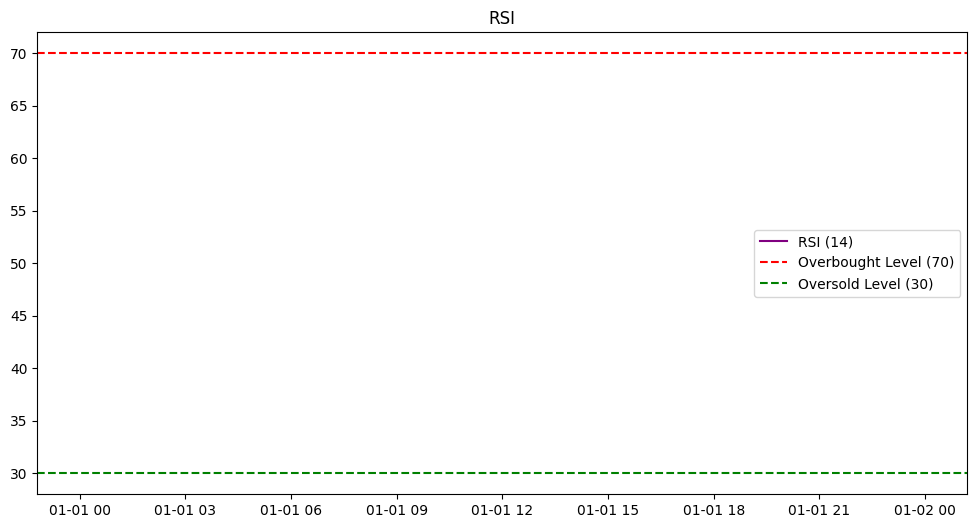

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(stock_data['RSI'], label='RSI (14)', color='purple')
plt.axhline(70, linestyle='--', color='red', label='Overbought Level (70)')
plt.axhline(30, linestyle='--', color='green', label='Oversold Level (30)')
plt.title('RSI')
plt.legend()
plt.show()


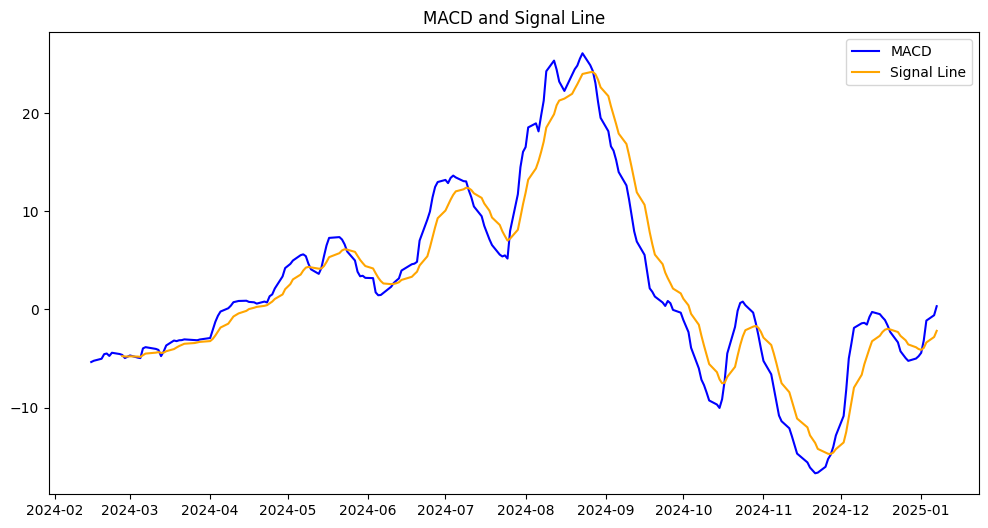

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(stock_data['MACD'], label='MACD', color='blue')
plt.plot(stock_data['Signal'], label='Signal Line', color='orange')
plt.title('MACD and Signal Line')
plt.legend()
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_7112\4196595765.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stock_data['Signal'][50:] = np.where(stock_data['SMA_50'][50:] > stock_data['SMA_200'][50:], 1, 0)  # Buy signal


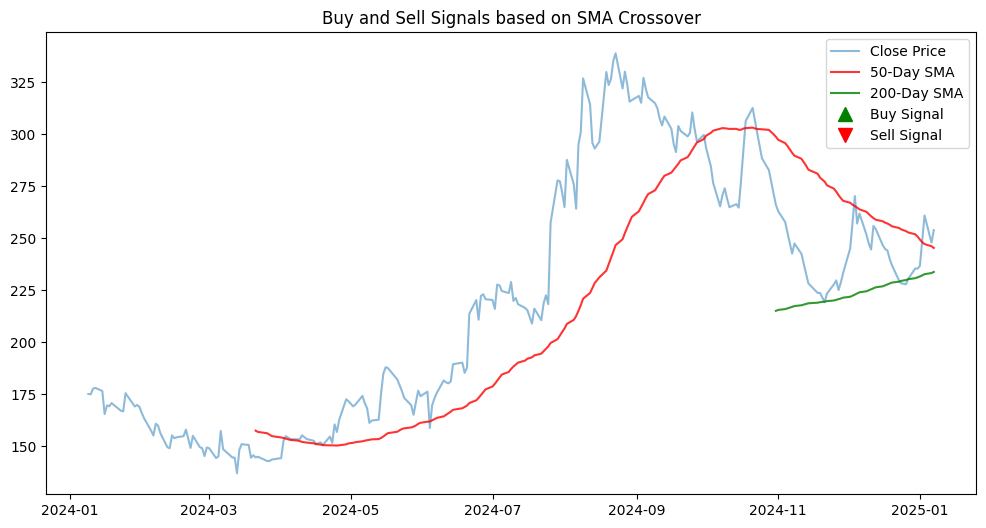

In [23]:
# Create Buy and Sell signals based on SMA crossover
stock_data['Signal'] = 0
stock_data['Signal'][50:] = np.where(stock_data['SMA_50'][50:] > stock_data['SMA_200'][50:], 1, 0)  # Buy signal
stock_data['Position'] = stock_data['Signal'].diff()  # Position change: 1 for buy, -1 for sell

# Plot buy and sell signals
plt.figure(figsize=(12, 6))
plt.plot(stock_data['Close'], label='Close Price', alpha=0.5)
plt.plot(stock_data['SMA_50'], label='50-Day SMA', color='red', alpha=0.8)
plt.plot(stock_data['SMA_200'], label='200-Day SMA', color='green', alpha=0.8)

# Plot Buy signals
plt.plot(stock_data[stock_data['Position'] == 1].index, 
         stock_data['SMA_50'][stock_data['Position'] == 1], 
         '^', markersize=10, color='green', label='Buy Signal')

# Plot Sell signals
plt.plot(stock_data[stock_data['Position'] == -1].index, 
         stock_data['SMA_50'][stock_data['Position'] == -1], 
         'v', markersize=10, color='red', label='Sell Signal')

plt.title('Buy and Sell Signals based on SMA Crossover')
plt.legend()
plt.show()


In [24]:
# Buy when RSI < 30 (Oversold), Sell when RSI > 70 (Overbought)
stock_data['Buy_Signal_RSI'] = np.where(stock_data['RSI'] < 30, 1, 0)
stock_data['Sell_Signal_RSI'] = np.where(stock_data['RSI'] > 70, 1, 0)

print(stock_data[['RSI', 'Buy_Signal_RSI', 'Sell_Signal_RSI']].tail())


Price                       RSI Buy_Signal_RSI Sell_Signal_RSI
Ticker                                                        
Date                                                          
2025-01-01 00:00:00+00:00  None              0               0
2025-01-02 00:00:00+00:00  None              0               0
2025-01-03 00:00:00+00:00  None              0               0
2025-01-06 00:00:00+00:00  None              0               0
2025-01-07 00:00:00+00:00  None              0               0


In [25]:
initial_balance = 10000
stock_data['Position'] = stock_data['Signal'].diff()

try: 
    # Simulate backtest
    balance = initial_balance
    positions = 0
    for i, row in stock_data.iterrows():
        # Ensure Position is not NaN and is either 1 or -1
        for j in range(len(row['Position'])-1):
            if pd.notna(row['Position']) and row['Position'][j] != 0:
                if row['Position'][j] == 1:  # Buy
                    positions = balance / row['Close']
                    balance = 0
                elif row['Position'][j] == -1:  # Sell
                    balance = positions * row['Close']
                    positions = 0
    
    final_balance = round((balance + (positions * stock_data['Close'].iloc[-1])),2)
    print(f"Final Portfolio Value: {final_balance}")
except ValueError as v:
    print("ValueError: ",v)
except ZeroDivisionError:
    print("Error: Division by zero is not allowed.")

Final Portfolio Value: Ticker
20MICRONS.NS    10000.0
Name: 2025-01-07 00:00:00+00:00, dtype: float64


### Sentiment Analysis

In [26]:
# Example: Load text data (e.g., a CSV file with tweets)
data = pd.read_csv('Tweets.csv')

# Preview the first few rows
# print(data.head())
data.head()

,tweet_id,user_id,user_name,user_screen_name,tweet_text,clean_text,created_at,retweet_count,favorite_count,reply_count,hashtags,mentions,location,language,source,in_reply_to_status_id,in_reply_to_user_id,sentiment_score,is_retweet
0,12345,54321,John Doe,@johndoe,Learning Python is fun! #coding,Learning Python is fun coding.,2024-11-08 10:00:00,10,15,2,#coding,@PythonHub,"Bangalore, IN",en,Twitter for iPhone,NaN,NaN,0.8,False


In [27]:
nltk.download('stopwords')

# Define stopwords
stop_words = set(stopwords.words('english'))

# Function to clean text
def clean_text(text):
    text = re.sub(r"http\S+", "", text)  # Remove URLs
    text = re.sub(r"@\w+", "", text)  # Remove mentions
    text = re.sub(r"[^A-Za-z\s]", "", text)  # Remove special characters
    text = " ".join([word.lower() for word in text.split() if word.lower() not in stop_words])  # Remove stopwords
    return text

# Apply cleaning to text data
data['clean_text'] = data['tweet_text'].apply(clean_text)

# Preview cleaned text
# print(data[['tweet_text', 'clean_text']].head())
data[['tweet_text', 'clean_text']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,tweet_text,clean_text
0,Learning Python is fun! #coding,learning python fun coding


In [28]:
# Function to get sentiment polarity
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

# Apply sentiment analysis
data['sentiment_textblob'] = data['clean_text'].apply(get_sentiment)

# Preview sentiment scores
# print(data[['clean_text', 'sentiment_textblob']].head())
data[['clean_text', 'sentiment_textblob']].head()

,clean_text,sentiment_textblob
0,learning python fun coding,0.3


In [29]:
# Initialize VADER sentiment analyzer
vader = SentimentIntensityAnalyzer()

# Function to get sentiment using VADER
def get_vader_sentiment(text):
    return vader.polarity_scores(text)['compound']

# Apply VADER sentiment analysis
data['sentiment_vader'] = data['clean_text'].apply(get_vader_sentiment)

# Preview sentiment scores
# print(data[['clean_text', 'sentiment_vader']].head())
data[['clean_text', 'sentiment_vader']].head()

,clean_text,sentiment_vader
0,learning python fun coding,0.5106


In [30]:
# Function to classify sentiment
def classify_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply classification to the VADER sentiment scores
data['sentiment_class'] = data['sentiment_vader'].apply(classify_sentiment)

# Preview classified sentiment
print(data[['clean_text', 'sentiment_vader', 'sentiment_class']].head())


                   clean_text  sentiment_vader sentiment_class
0  learning python fun coding           0.5106        Positive


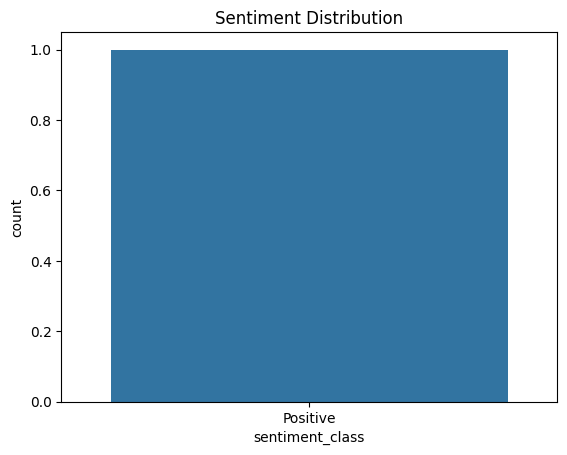

In [31]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# Plot sentiment distribution
sns.countplot(x='sentiment_class', data=data)
plt.title('Sentiment Distribution')
plt.show()


In [32]:
# Load a pre-trained sentiment analysis pipeline
sentiment_pipeline = pipeline('sentiment-analysis', framework='pt')

# Apply the sentiment pipeline
results = sentiment_pipeline(data['clean_text'].tolist())

# Convert the results to a DataFrame
sentiment_df = pd.DataFrame(results)

# Merge results with original data
data = pd.concat([data, sentiment_df], axis=1)

# Preview the results
print(data[['clean_text', 'label', 'score']].head())


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


                   clean_text     label     score
0  learning python fun coding  POSITIVE  0.999301


### Quantitative Analysis

In [33]:
# Preview the data
# print(stock_data.head())
stock_data.head()

Price,Adj Close,Close,High,Low,Open,Volume,SMA_50,SMA_200,EMA_50,RSI,MACD,Histogram,Signal,Position,Buy_Signal_RSI,Sell_Signal_RSI
Ticker,20MICRONS.NS,20MICRONS.NS,20MICRONS.NS,20MICRONS.NS,20MICRONS.NS,20MICRONS.NS,,,,,,,,,,
Date,,,,,,,,,,,,,,,,
2024-01-09 00:00:00+00:00,174.210617,175.199997,179.949997,172.350006,177.050003,158254,NaN,NaN,175.199997,None,NaN,NaN,0,NaN,0,0
2024-01-10 00:00:00+00:00,174.061462,175.050003,176.949997,173.449997,175.199997,68214,NaN,NaN,175.194115,None,NaN,NaN,0,0.0,0,0
2024-01-11 00:00:00+00:00,176.746216,177.750000,179.300003,175.100006,178.000000,114645,NaN,NaN,175.294346,None,NaN,NaN,0,0.0,0,0
2024-01-12 00:00:00+00:00,177.143951,178.149994,181.850006,177.000000,179.899994,144150,NaN,NaN,175.406332,None,NaN,NaN,0,0.0,0,0
2024-01-15 00:00:00+00:00,175.652420,176.649994,183.000000,175.250000,181.649994,136183,NaN,NaN,175.455103,None,NaN,NaN,0,0.0,0,0


In [34]:
# Calculate basic statistics for the closing price
mean_price = stock_data['Close'].mean()
median_price = stock_data['Close'].median()
std_dev_price = stock_data['Close'].std()
variance_price = stock_data['Close'].var()

print(f"Mean Price: {mean_price}")
print(f"Median Price: {median_price}")
print(f"Standard Deviation: {std_dev_price}")
print(f"Variance: {variance_price}")

Mean Price: Ticker
20MICRONS.NS    220.084367
dtype: float64
Median Price: Ticker
20MICRONS.NS    220.410004
dtype: float64
Standard Deviation: Ticker
20MICRONS.NS    58.78091
dtype: float64
Variance: Ticker
20MICRONS.NS    3455.195405
dtype: float64


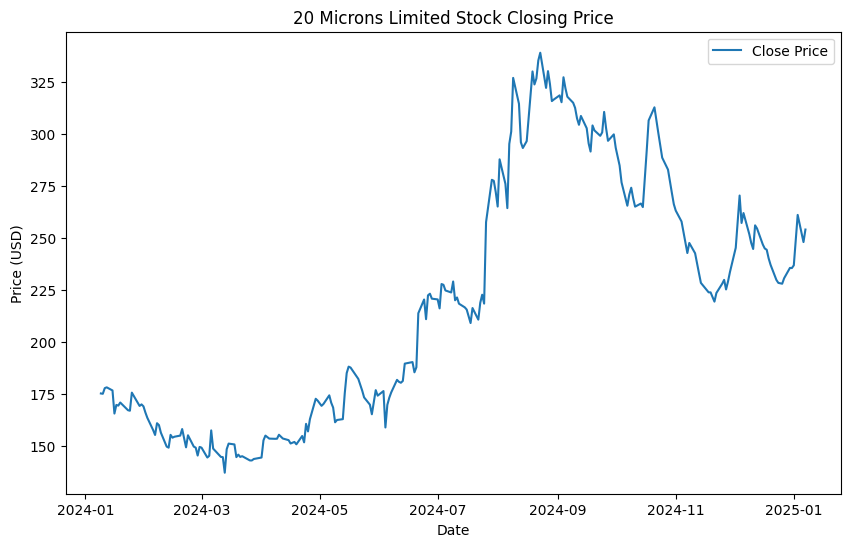

In [35]:
# Plot the closing price
plt.figure(figsize=(10, 6))
plt.plot(stock_data['Close'], label='Close Price')
plt.title(f'{companyName} Stock Closing Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()


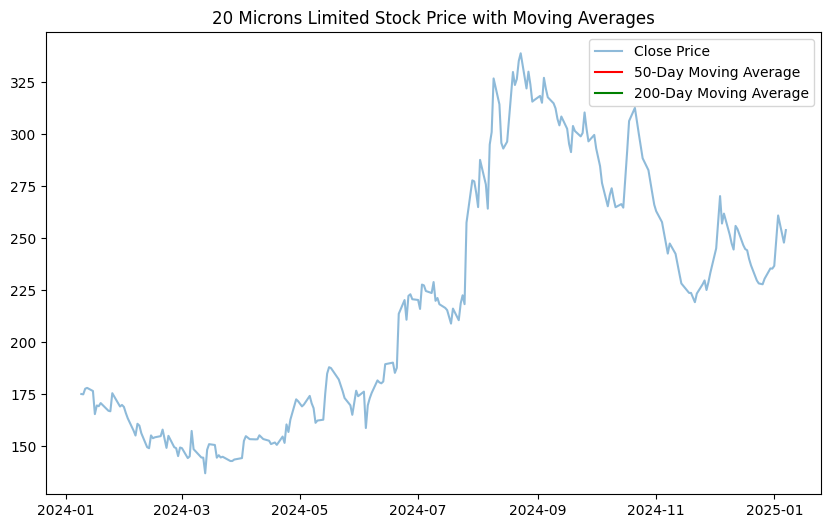

In [36]:
# Calculate 50-day and 200-day moving averages
stock_data['SMA_50'] = stock_data['Close'].rolling(window=50).mean()
stock_data['SMA_200'] = stock_data['Close'].rolling(window=200).mean()

# Plot the moving averages
plt.figure(figsize=(10, 6))
plt.plot(stock_data['Close'], label='Close Price', alpha=0.5)
plt.plot(stock_data['SMA_50'], label='50-Day Moving Average', color='red')
plt.plot(stock_data['SMA_200'], label='200-Day Moving Average', color='green')
plt.title(f'{companyName} Stock Price with Moving Averages')
plt.legend()
plt.show()


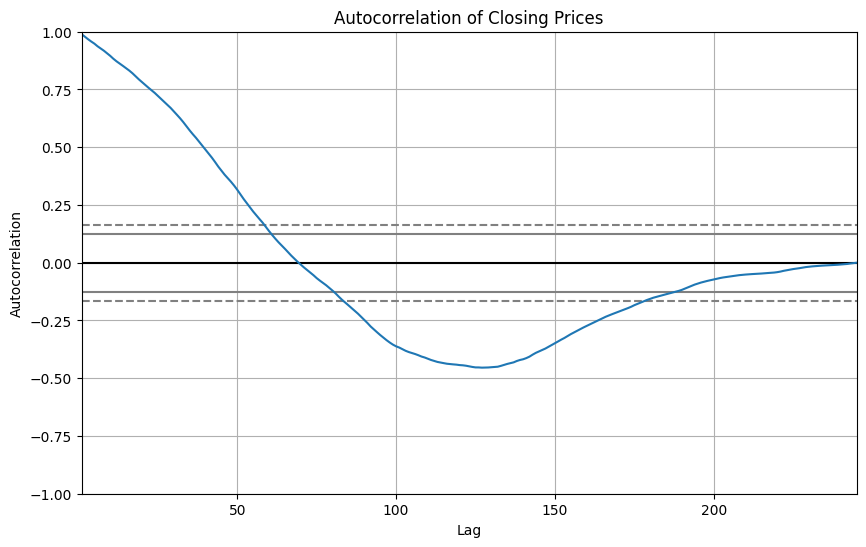

In [37]:
# Plot autocorrelation
plt.figure(figsize=(10, 6))
autocorrelation_plot(stock_data['Close'])
plt.title('Autocorrelation of Closing Prices')
plt.show()


In [38]:
# Perform ADF test
result = adfuller(stock_data['Close'])
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")


ADF Statistic: -1.090398412893738
p-value: 0.7188856788636426


In [39]:
# Create a linear regression model (dependent variable: Close, independent variable: time)
stock_data['Date_Num'] = pd.to_numeric(stock_data.index)  # Convert date to numeric for regression
X = stock_data['Date_Num']
y = stock_data['Close']

# Add a constant to the independent variable for intercept
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Print the regression summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           20MICRONS.NS   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                       nan
Date:                Tue, 07 Jan 2025   Prob (F-statistic):                nan
Time:                        14:04:17   Log-Likelihood:                -1341.6
No. Observations:                 245   AIC:                             2685.
Df Residuals:                     244   BIC:                             2689.
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       7.442e-35   1.25e-36     59.551      0.0

In [40]:
# Example: Multiple regression with stock price vs Date and Volume
X = stock_data[['Date_Num', 'Volume']]
y = stock_data['Close']

# Add constant for intercept
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Print the summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           20MICRONS.NS   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.041
Method:                 Least Squares   F-statistic:                     11.51
Date:                Tue, 07 Jan 2025   Prob (F-statistic):           0.000807
Time:                        14:04:17   Log-Likelihood:                -1339.6
No. Observations:                 245   AIC:                             2683.
Df Residuals:                     243   BIC:                             2690.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

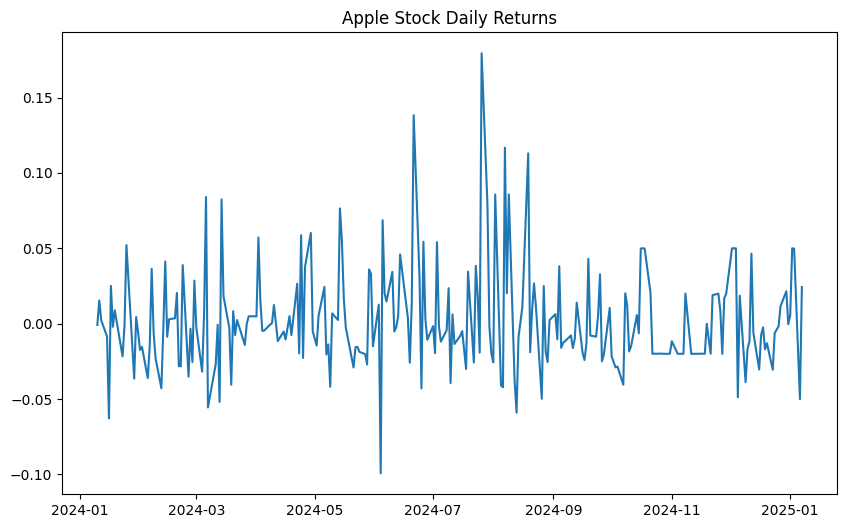

In [41]:
# Calculate daily returns
stock_data['Daily_Return'] = stock_data['Close'].pct_change()

# Plot daily returns
plt.figure(figsize=(10, 6))
plt.plot(stock_data['Daily_Return'], label='Daily Return')
plt.title('Apple Stock Daily Returns')
plt.show()


In [42]:
# Calculate annualized Sharpe Ratio
risk_free_rate = 0.01  # Example: 1% risk-free rate
sharpe_ratio = (stock_data['Daily_Return'].mean() - risk_free_rate / 252) / stock_data['Daily_Return'].std() * (252**0.5)
print(f"Sharpe Ratio: {sharpe_ratio}")


Sharpe Ratio: 0.9510954899146717


C:\Users\Admin\AppData\Local\Temp\ipykernel_7112\1831394805.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  simulation_matrix[0, i] = price


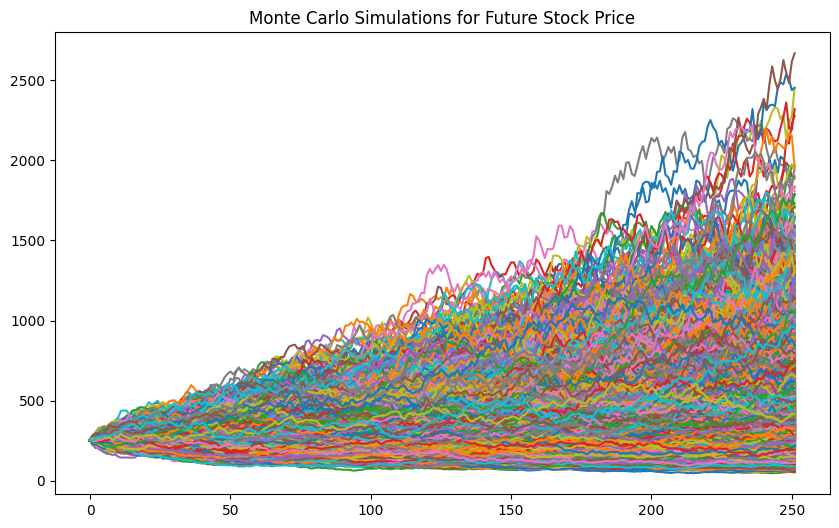

In [43]:
# Simulate 10,000 scenarios for future stock price
num_simulations = 10000
simulation_days = 252  # Number of trading days in a year
price = stock_data['Close'].iloc[-1]
daily_return = stock_data['Daily_Return'].mean()
daily_volatility = stock_data['Daily_Return'].std()

# Create a matrix to store the simulations
simulation_matrix = np.zeros((simulation_days, num_simulations))

for i in range(num_simulations):
    simulation_matrix[0, i] = price
    for j in range(1, simulation_days):
        simulation_matrix[j, i] = simulation_matrix[j-1, i] * np.exp((daily_return - 0.5 * daily_volatility**2) +
                                                                     daily_volatility * np.random.normal())

# Plot the simulation results
plt.figure(figsize=(10, 6))
plt.plot(simulation_matrix)
plt.title('Monte Carlo Simulations for Future Stock Price')
plt.show()


### Risk Management and Diversification

In [44]:
# Download historical stock price data for multiple stocks
assets = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
data = yf.download(assets, start='2023-01-01', end='2024-01-01')['Adj Close']

# Preview the data
# print(data.head())
data.head()

[*********************100%***********************]  4 of 4 completed


Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2023-01-03 00:00:00+00:00,123.768463,85.820000,88.798103,236.183502
2023-01-04 00:00:00+00:00,125.045036,85.139999,87.761856,225.852097
2023-01-05 00:00:00+00:00,123.718971,83.120003,85.888649,219.158340
2023-01-06 00:00:00+00:00,128.271103,86.080002,87.024529,221.741196
2023-01-09 00:00:00+00:00,128.795578,87.360001,87.702072,223.900162


In [45]:
# Calculate daily returns
returns = data.pct_change().dropna()

# Preview daily returns
# print(returns.head())
returns.head()

Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2023-01-04 00:00:00+00:00,0.010314,-0.007924,-0.011670,-0.043743
2023-01-05 00:00:00+00:00,-0.010605,-0.023726,-0.021344,-0.029638
2023-01-06 00:00:00+00:00,0.036794,0.035611,0.013225,0.011785
2023-01-09 00:00:00+00:00,0.004089,0.014870,0.007786,0.009736
2023-01-10 00:00:00+00:00,0.004457,0.028732,0.004544,0.007617


In [46]:
# Assign equal weights for a simple diversified portfolio
weights = [0.25, 0.25, 0.25, 0.25]  # Equal weighting for 4 stocks

# Verify the sum of weights (should be 1)
print(f"sum of weights: {sum(weights)}")

# Calculate the expected portfolio return
expected_portfolio_return = (returns.mean() * weights).sum()

print(f"Expected Portfolio Return: {expected_portfolio_return:.4f}")

# Calculate covariance matrix of returns
cov_matrix = returns.cov()

# Calculate portfolio volatility (standard deviation of returns)
portfolio_volatility = np.sqrt(np.dot(weights, np.dot(cov_matrix, weights))) * np.sqrt(252)  # Annualized volatility

print(f"Portfolio Volatility (Annualized): {portfolio_volatility:.4f}")

risk_free_rate = 0.01  # Example risk-free rate (1%)

# Calculate Sharpe Ratio
sharpe_ratio = (expected_portfolio_return - risk_free_rate) / portfolio_volatility

print(f"Sharpe Ratio: {sharpe_ratio:.4f}")


sum of weights: 1.0
Expected Portfolio Return: 0.0021
Portfolio Volatility (Annualized): 0.2202
Sharpe Ratio: -0.0360


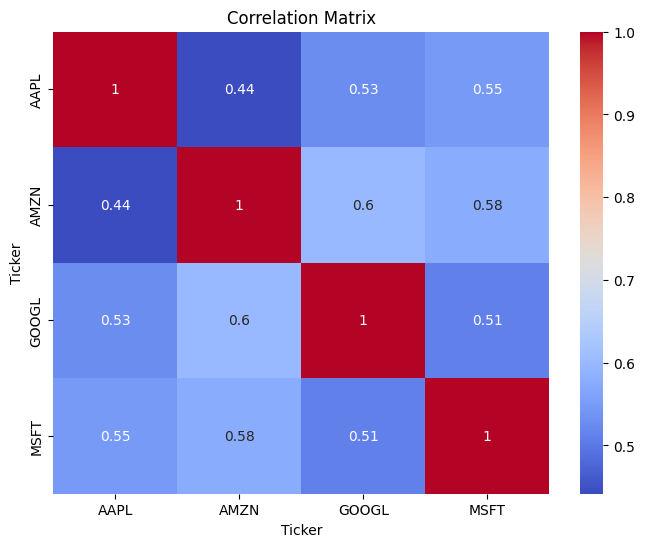

In [47]:
# Calculate correlation matrix
correlation_matrix = returns.corr()

# Visualize the correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


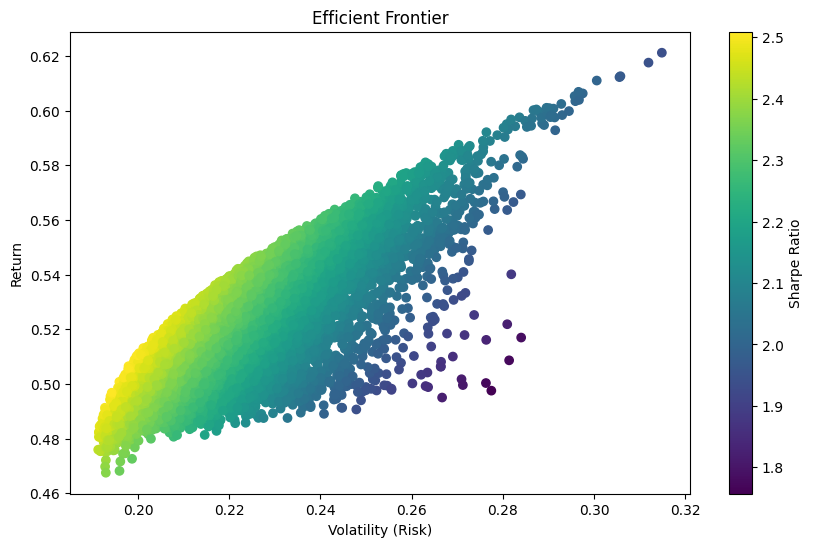

In [48]:
# Number of portfolios to simulate
num_portfolios = 10000
all_weights = np.zeros((num_portfolios, len(assets)))
ret_arr = np.zeros(num_portfolios)
vol_arr = np.zeros(num_portfolios)
sharpe_arr = np.zeros(num_portfolios)

# Loop through random portfolios
for i in range(num_portfolios):
    # Generate random weights for each asset
    weights = np.random.random(len(assets))
    weights /= np.sum(weights)  # Normalize weights to sum to 1

    # Save weights
    all_weights[i, :] = weights

    # Expected return for the portfolio
    ret_arr[i] = np.sum(returns.mean() * weights) * 252

    # Expected volatility
    vol_arr[i] = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(252)

    # Sharpe Ratio
    sharpe_arr[i] = (ret_arr[i] - risk_free_rate) / vol_arr[i]

# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(vol_arr, ret_arr, c=sharpe_arr, cmap='viridis')
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Return')
plt.title('Efficient Frontier')
plt.show()


In [49]:
# Find the index of the portfolio with the maximum Sharpe Ratio
max_sharpe_idx = sharpe_arr.argmax()

# Extract the optimal portfolio's information
optimal_weights = all_weights[max_sharpe_idx]
optimal_return = ret_arr[max_sharpe_idx]
optimal_volatility = vol_arr[max_sharpe_idx]
optimal_sharpe = sharpe_arr[max_sharpe_idx]

print(f"Optimal Weights: {optimal_weights}")
print(f"Expected Return: {optimal_return:.4f}")
print(f"Volatility: {optimal_volatility:.4f}")
print(f"Sharpe Ratio: {optimal_sharpe:.4f}")


Optimal Weights: [0.58077614 0.21761655 0.00988872 0.19171859]
Expected Return: 0.5065
Volatility: 0.1979
Sharpe Ratio: 2.5089


In [50]:
# Calculate 5% Value at Risk (VaR)
VaR_95 = np.percentile(returns['AAPL'], 5)

print(f"95% Historical Value at Risk (AAPL): {VaR_95:.4f}")


95% Historical Value at Risk (AAPL): -0.0172


In [51]:
# Generate Monte Carlo simulations for future price movements
num_simulations = 10000
simulation_days = 252
price = data['AAPL'].iloc[-1]
daily_return = returns['AAPL'].mean()
daily_volatility = returns['AAPL'].std()

simulations = np.zeros((num_simulations, simulation_days))
for i in range(num_simulations):
    simulations[i, 0] = price
    for j in range(1, simulation_days):
        simulations[i, j] = simulations[i, j-1] * np.exp((daily_return - 0.5 * daily_volatility**2) + daily_volatility * np.random.normal())

# Calculate the 5% VaR from simulated results
sim_end_prices = simulations[:, -1]
VaR_95_mc = np.percentile(sim_end_prices, 5)

print(f"95% Monte Carlo Value at Risk (AAPL): {VaR_95_mc:.2f}")


95% Monte Carlo Value at Risk (AAPL): 213.51


In [52]:
# Simulate a market crash where all asset prices drop by 20%
market_crash = data * 0.8

# Recalculate returns, portfolio volatility, and risk metrics under stress
crash_returns = market_crash.pct_change().dropna()

# Portfolio performance under stress
crash_portfolio_return = (crash_returns.mean() * weights).sum()
crash_portfolio_volatility = np.sqrt(np.dot(weights, np.dot(crash_returns.cov(), weights))) * np.sqrt(252)

print(f"Portfolio Return during Market Crash: {crash_portfolio_return:.4f}")
print(f"Portfolio Volatility during Market Crash: {crash_portfolio_volatility:.4f}")


Portfolio Return during Market Crash: 0.0020
Portfolio Volatility during Market Crash: 0.2118


### Macroeconomic Analysis

In [53]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import urllib3

# Suppress SSL warnings
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

url = 'https://www.investing.com/economic-calendar/'

# Send a request to the website
response = requests.get(url, verify=False)
soup = BeautifulSoup(response.text, 'html.parser')

# Find the table containing the macroeconomic data
table = soup.find('table', {'id': 'economicCalendarData'})

# Parse the table
rows = table.find_all('tr')

data = []
for row in rows:
    cols = row.find_all('td')
    data.append([col.text.strip() for col in cols])

# Convert the list of data into a DataFrame
df = pd.DataFrame(data) #, columns=["Date", "Cur.", "Imp.", "Event", "Actual", "Forecast", "Previous"])
# print(df.head())
df.head()

,0,1,2,3,4,5,6,7
0,None,None,None,None,None,None,None,None
1,None,None,None,None,None,None,None,None
2,"Tuesday, January 7, 2025",None,None,None,None,None,None,None
3,All Day,,Holiday,Russia - Christmas,None,None,None,None
4,02:00,GBP,,Halifax House Price Index (MoM) (Dec),-0.2%,0.8%,1.2%,


In [54]:
# Example URL (you would need to adjust this to the exact data source)
url = 'https://www.rbi.org.in/Scripts/BS_viewWss.aspx' # 'https://www.rbi.org.in/Scripts/WSSView.aspx'

# Send a GET request
response = requests.get(url)
# print(response.text)
# Assuming the data is in CSV format (parse it if necessary)
# Save data as CSV or extract the relevant data fields
# For example, use Pandas to process CSV data
if response.status_code == 200:
    soup = BeautifulSoup(response.content, 'html.parser')
    # Extract Year options
    year_select = soup.find('select', {'id': 'ddlYear'})
    years = [option.text for option in year_select.find_all('option')]
    
    # Extract Month options
    month_select = soup.find('select', {'id': 'ddlMonth'})
    months = [option.text for option in month_select.find_all('option')]
    
    # Extract Archive section options
    section_select = soup.find('select', {'id': 'ddlSection'})
    sections = [option.text for option in section_select.find_all('option')]
    
    print(len(years), len(months), len(sections))
    min_length = min(len(years), len(months), len(sections))
    years = years[:min_length]
    months = months[:min_length]
    sections = sections[:min_length]
    
    # Create a DataFrame
    data = {
        'Year Options': years,
        'Month Options': months,
        'Archive Sections': sections
    }


    df = pd.DataFrame(data)
    
    # Display the DataFrame
    print(df)
else:
    print("Failed to retrieve the page:", response.status_code)

32 13 27
   Year Options Month Options  \
0   Select Year  Select Month   
1          2025       January   
2          2024      Feburary   
3          2023         March   
4          2022         April   
5          2021           May   
6          2020          June   
7          2019          July   
8          2018        August   
9          2017     September   
10         2016       October   
11         2015      November   
12         2014      December   

                                     Archive Sections  
0                              Select SubSection Name  
1                               Reserve Bank of India  
2                           Foreign Exchange Reserves  
3      Scheduled Commercial Banks - Business in India  
4               Cash Reserve Ratio and Interest Rates  
5                                       Accommodation  
6    Foreign Exchange Rates - Spot and Forward Premia  
7                Money Stock : Components and Sources  
8              Reserve M

In [55]:
# Initialize the FRED API with your API key
fred = Fred(api_key='306e52b9780383dc719c1a16aae0a44b')

# gdp = fred.search('Consumer Price Indices (CPIs, HICPs), COICOP 1999: Consumer Price Index: Total for India')
# infl = fred.search('Inflation, consumer prices for India')
# intr_Rate = fred.search('Interest Rates: Long-Term Government Bond Yields: 10-Year: Main (Including Benchmark) for India')
# unemp_Rate = fred.search('Youth Unemployment Rate for India')
# indProd_Rate = fred.search('Production: Manufacturing: Total Manufacturing for India')

gdp_growth = fred.get_series('INDCPIALLMINMEI', )  # Change the ID for Indian GDP
inflation = fred.get_series('FPCPITOTLZGIND')  # Change the ID for Indian Inflation

interest_rate = fred.get_series('INDIRLTLT01STM')  # Change the ID for Indian Interest Rate
unemployment_rate = fred.get_series('SLUEM1524ZSIND')  # Change the ID for Unemployment Rate

industrial_production = fred.get_series('INDPRMNTO01GYSAM')  # Change the ID for Industrial Production

# Preview the GDP data
data = {'GDP Growth': gdp_growth, 'Inflation': inflation, 'Interest Rate': interest_rate, 
        'Unemployment Rate': unemployment_rate, 'Industrial Production': industrial_production}

macro_data = pd.DataFrame(data)
macro_data.dropna(inplace=True)
# print(macro_data.head())
macro_data.head()

,GDP Growth,Inflation,Interest Rate,Unemployment Rate,Industrial Production
2012-01-01,75.74116,9.478997,8.24,20.628,0.973930
2013-01-01,84.53937,10.017878,7.87,21.451,-2.695954
2014-01-01,90.65987,6.665657,8.76,22.251,4.928414
2015-01-01,97.16290,4.906973,7.79,23.075,2.318650
2016-01-01,102.90090,4.948216,7.67,23.954,4.393797


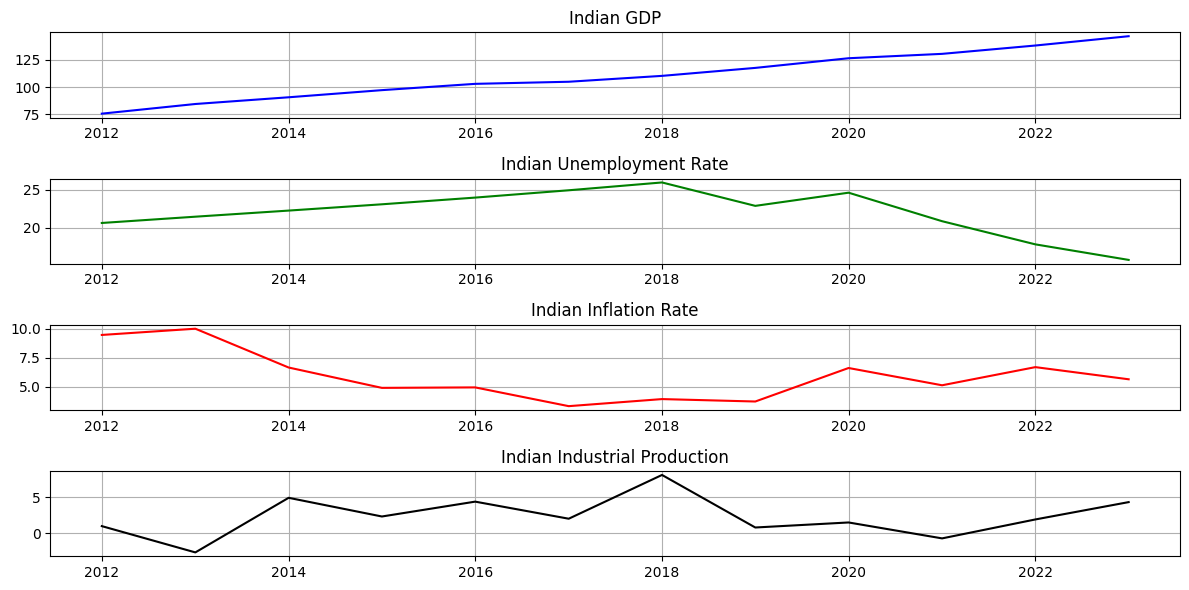

In [56]:
# Plot GDP, unemployment, and inflation
plt.figure(figsize=(12, 6))

plt.subplot(4, 1, 1)
plt.plot(macro_data.index, macro_data['GDP Growth'], label='GDP', color='blue')
plt.title('Indian GDP')
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(macro_data.index, macro_data['Unemployment Rate'], label='Unemployment Rate', color='green')
plt.title('Indian Unemployment Rate')
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(macro_data.index, macro_data['Inflation'], label='Inflation Rate', color='red')
plt.title('Indian Inflation Rate')
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(macro_data.index, macro_data['Industrial Production'], label='Industrial Production', color='black')
plt.title('Indian Industrial Production')
plt.grid(True)

plt.tight_layout()
plt.show()

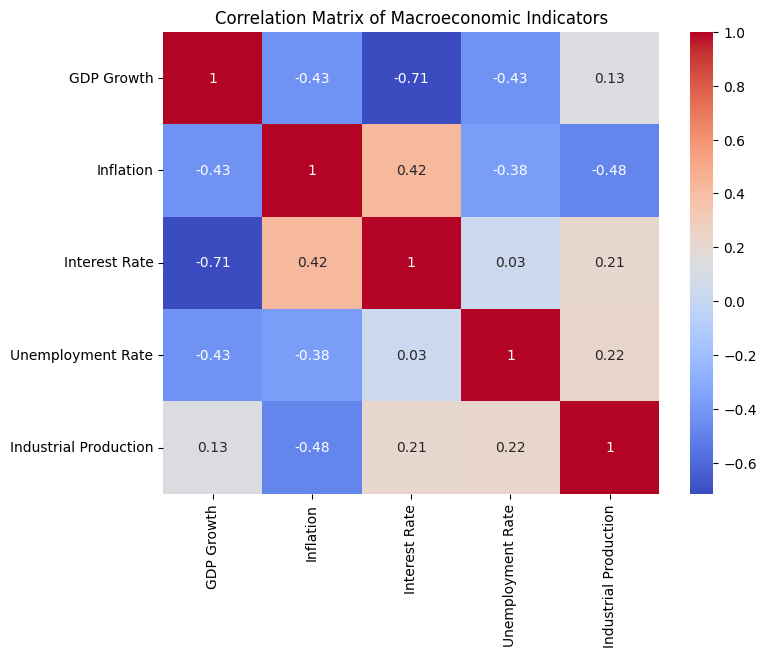

In [57]:
# Calculate the correlation matrix
correlation_matrix = macro_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Macroeconomic Indicators')
plt.show()

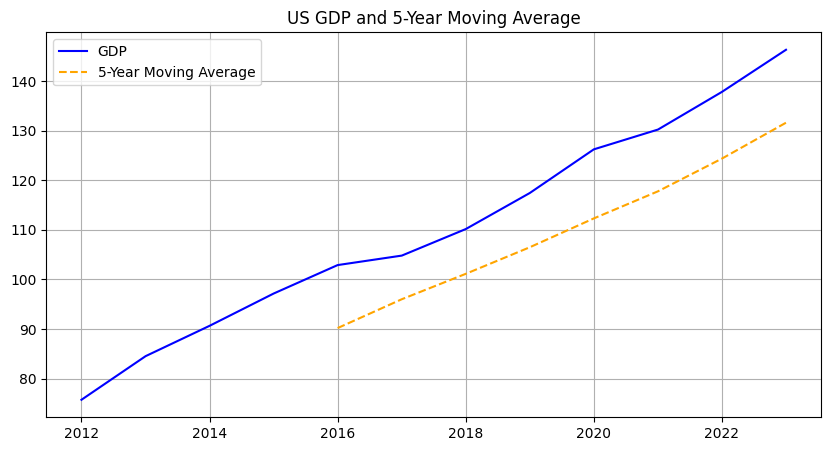

In [58]:
# Calculate moving averages for GDP
macro_data['GDP_MA'] = macro_data['GDP Growth'].rolling(window=5).mean()

# Plot GDP and its moving average
plt.figure(figsize=(10, 5))
plt.plot(macro_data['GDP Growth'], label='GDP', color='blue')
plt.plot(macro_data['GDP_MA'], label='5-Year Moving Average', color='orange', linestyle='--')
plt.title('US GDP and 5-Year Moving Average')
plt.legend()
plt.grid(True)
plt.show()

In [59]:
# Perform ADF test on GDP
adf_test = adfuller(macro_data['GDP Growth'])
print(f"ADF Statistic: {adf_test[0]}")
print(f"p-value: {adf_test[1]}")

# If p-value < 0.05, the series is stationary


ADF Statistic: 47.18660395551958
p-value: 1.0


In [60]:
# Define independent (X) and dependent (Y) variables
X = macro_data['Unemployment Rate']
Y = macro_data['GDP Growth']

# Add a constant for the intercept
X = sm.add_constant(X)

# Fit the linear regression model
model = sm.OLS(Y, X).fit()

# Print the regression summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:             GDP Growth   R-squared:                       0.181
Model:                            OLS   Adj. R-squared:                  0.099
Method:                 Least Squares   F-statistic:                     2.210
Date:                Tue, 07 Jan 2025   Prob (F-statistic):              0.168
Time:                        14:07:40   Log-Likelihood:                -52.325
No. Observations:                  12   AIC:                             108.6
Df Residuals:                      10   BIC:                             109.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               179.6418     47.00

E:\Softwares\Installation Files\Python_312\Lib\site-packages\scipy\stats\_stats_py.py:1971: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=12
  k, _ = kurtosistest(a, axis)


In [61]:
# Define multiple independent variables (Unemployment and Inflation)
X_multi = macro_data[['Unemployment Rate', 'Inflation']]
X_multi = sm.add_constant(X_multi)

# Fit the model
model_multi = sm.OLS(Y, X_multi).fit()

# Print the regression summary
print(model_multi.summary())


                            OLS Regression Results                            
Dep. Variable:             GDP Growth   R-squared:                       0.583
Model:                            OLS   Adj. R-squared:                  0.491
Method:                 Least Squares   F-statistic:                     6.298
Date:                Tue, 07 Jan 2025   Prob (F-statistic):             0.0195
Time:                        14:07:40   Log-Likelihood:                -48.271
No. Observations:                  12   AIC:                             102.5
Df Residuals:                       9   BIC:                             104.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               263.8808     45.45

E:\Softwares\Installation Files\Python_312\Lib\site-packages\scipy\stats\_stats_py.py:1971: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=12
  k, _ = kurtosistest(a, axis)


E:\Softwares\Installation Files\Python_312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                               SARIMAX Results                                
Dep. Variable:             GDP Growth   No. Observations:                   12
Model:                 ARIMA(5, 1, 0)   Log Likelihood                 -26.404
Date:                Tue, 07 Jan 2025   AIC                             64.809
Time:                        14:07:47   BIC                             67.196
Sample:                    01-01-2012   HQIC                            63.304
                         - 01-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5157      0.441      1.168      0.243      -0.349       1.381
ar.L2          0.0860      0.457      0.188      0.851      -0.809       0.981
ar.L3          0.1480      0.409      0.361      0.7

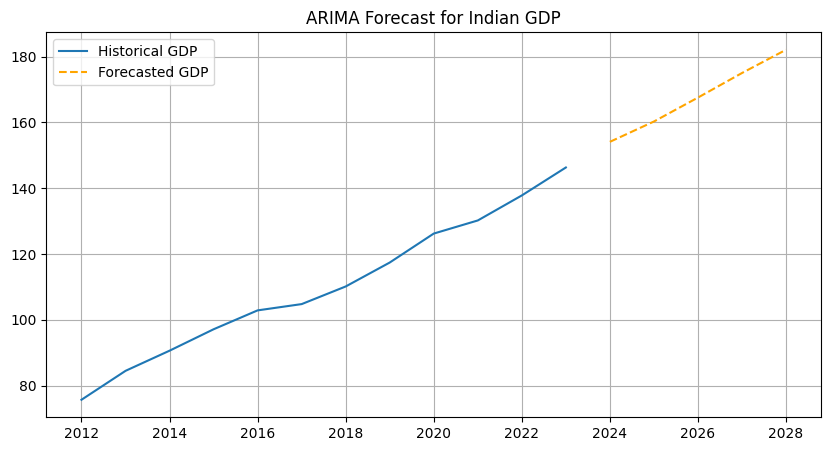

In [62]:
# Fit ARIMA model to GDP data
model = ARIMA(macro_data['GDP Growth'], order=(5, 1, 0))  # Order (p, d, q)
arima_result = model.fit()

# Print model summary
print(arima_result.summary())

# Forecast future GDP values
forecast = arima_result.forecast(steps=5)
print(forecast)

# Plot the forecasted values
plt.figure(figsize=(10, 5))
plt.plot(macro_data['GDP Growth'], label='Historical GDP')
plt.plot(forecast, label='Forecasted GDP', color='orange', linestyle='--')
plt.title('ARIMA Forecast for Indian GDP')
plt.legend()
plt.grid(True)
plt.show()


[*********************100%***********************]  1 of 1 completed


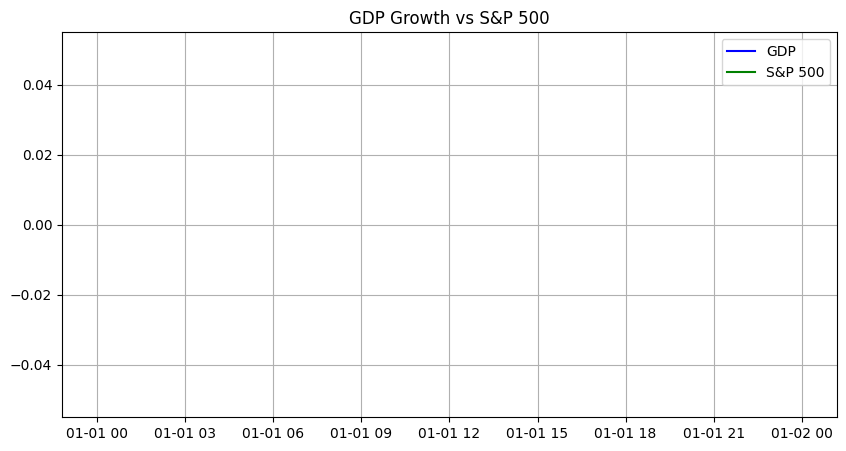

Correlation between GDP and S&P 500: nan


In [63]:
# Download historical S&P 500 data
sp500 = yf.download(tickersListName, start=startDate, end=endDate)['Adj Close']

# Merge with macroeconomic data
macro_data['SP500'] = sp500.resample('YE').mean()  # Annual resampling

# Drop missing values
macro_data.dropna(inplace=True)

# Plot the relationship between GDP and S&P 500
plt.figure(figsize=(10, 5))
plt.plot(macro_data['GDP Growth'], label='GDP', color='blue')
plt.plot(macro_data['SP500'], label='S&P 500', color='green')
plt.title('GDP Growth vs S&P 500')
plt.legend()
plt.grid(True)
plt.show()

# Calculate correlation between GDP and S&P 500
correlation = macro_data['GDP Growth'].corr(macro_data['SP500'])
print(f"Correlation between GDP and S&P 500: {correlation:.4f}")


### Old Techniques in ML

In [64]:
del tickHistory["Dividends"]
del tickHistory["Stock Splits"]
tickHistory["Tomorrow"] = tickHistory["Close"].shift(-1)

In [65]:
tickHistory["Target"] = (tickHistory['Tomorrow'] > tickHistory['Close']).astype(int)
# print(round(tickerName, 2))

In [66]:
tickHistory = tickHistory.loc["1990-01-01":].copy()
# print(round(tickHistory, 2))
tickHistory

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
2008-10-06 00:00:00+05:30,34.939769,34.939769,13.801209,14.652865,23501600,13.124249,0
2008-10-07 00:00:00+05:30,13.975907,16.596389,12.163406,13.124249,9113400,11.573798,0
2008-10-08 00:00:00+05:30,12.228919,12.753016,10.962352,11.573798,2464384,10.132532,0
2008-10-10 00:00:00+05:30,10.875002,10.875002,9.455574,10.132532,1207928,10.765816,1
2008-10-13 00:00:00+05:30,10.612954,11.617473,10.176207,10.765816,898692,9.673948,0
...,...,...,...,...,...,...,...
2025-01-01 00:00:00+05:30,235.479996,239.449997,232.050003,236.809998,38786,248.649994,1
2025-01-02 00:00:00+05:30,239.399994,248.649994,236.119995,248.649994,82081,261.029999,1
2025-01-03 00:00:00+05:30,255.899994,261.079987,248.500000,261.029999,102182,247.970001,0


In [67]:
model = RandomForestClassifier(n_estimators=100, min_samples_split=100, random_state=1)

train = tickHistory.iloc[:-100]
test = tickHistory.iloc[-100:]

predictors = ["Close", "Volume", "Open", "High", "Low"]
model.fit(train[predictors], train["Target"])

RandomForestClassifier(min_samples_split=100, random_state=1)

In [68]:
preds = model.predict(test[predictors])
preds = pd.Series(preds, index=test.index)
# print(preds)

In [69]:
precision_score(test["Target"], preds, average='weighted', zero_division=0)

0.38439999999999996

<Axes: xlabel='Date'>

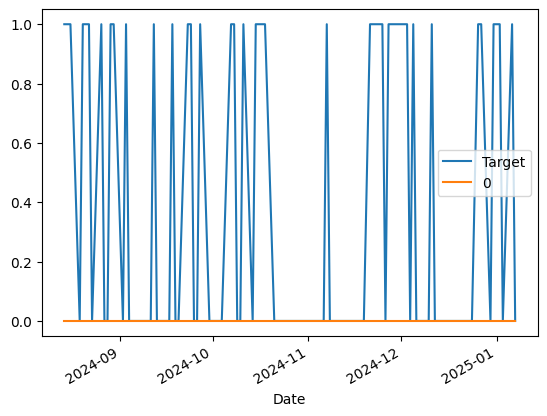

In [70]:
combined = pd.concat([test["Target"], preds], axis=1)
combined.plot()

In [71]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined


def backtest(data, model, predictors, start=2500, step=250):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)

    return pd.concat(all_predictions)

In [72]:
predictions = backtest(tickHistory, model, predictors)
print(predictions["Predictions"].value_counts())
print()
print("Prediction Score: ", precision_score(predictions["Target"], predictions["Predictions"]))
print()
print(predictions["Target"].value_counts() / predictions.shape[0])

Predictions
0    1176
1     329
Name: count, dtype: int64

Prediction Score:  0.425531914893617

Target
0    0.542857
1    0.457143
Name: count, dtype: float64


In [73]:
horizons = [2,5,50,60,200,250,1000]
new_predictors = []

for horizon in horizons:
    rolling_averages = tickHistory.rolling(horizon).mean()

    ratio_column = f"Close_Ratio_{horizon}"
    tickHistory[ratio_column] = tickHistory["Close"] / rolling_averages["Close"]

    trend_column = f"Trend_{horizon}"
    tickHistory[trend_column] = tickHistory.shift(1).rolling(horizon).sum()["Target"]

    new_predictors+= [ratio_column, trend_column]

In [74]:
tickHistory = tickHistory.dropna(subset=tickHistory.columns[tickHistory.columns != "Tomorrow"])
# print(round(tickHistory, 2))
tickHistory

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,...,Close_Ratio_50,Trend_50,Close_Ratio_60,Trend_60,Close_Ratio_200,Trend_200,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,,,,,
2012-10-30 00:00:00+05:30,51.768280,53.307339,51.301899,52.840958,428564,53.377293,1,1.013643,2.0,1.021825,...,0.951829,22.0,0.966545,27.0,1.234016,95.0,1.326369,116.0,2.316992,449.0
2012-10-31 00:00:00+05:30,53.167423,54.053547,52.817637,53.377293,285194,58.577442,1,1.005049,2.0,1.024436,...,0.962080,23.0,0.973946,28.0,1.242913,96.0,1.336443,116.0,2.336385,450.0
2012-11-01 00:00:00+05:30,53.633805,59.976588,53.633805,58.577442,1841120,69.047691,1,1.046449,2.0,1.095031,...,1.054213,24.0,1.064505,29.0,1.359290,96.0,1.462555,116.0,2.558737,451.0
2012-11-02 00:00:00+05:30,58.554121,69.863858,58.530801,69.047691,6974242,76.439835,1,1.082039,2.0,1.210251,...,1.236037,25.0,1.245766,30.0,1.594791,97.0,1.717427,116.0,3.008349,452.0
2012-11-05 00:00:00+05:30,69.957142,79.704501,69.957142,76.439835,8132200,74.481033,0,1.050809,2.0,1.231775,...,1.357924,25.0,1.366792,30.0,1.755800,98.0,1.892776,116.0,3.320916,452.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-01 00:00:00+05:30,235.479996,239.449997,232.050003,236.809998,38786,248.649994,1,1.002816,1.0,1.015123,...,0.949227,15.0,0.933187,21.0,1.023812,84.0,1.088753,102.0,2.053920,469.0
2025-01-02 00:00:00+05:30,239.399994,248.649994,236.119995,248.649994,82081,261.029999,1,1.024389,2.0,1.047300,...,1.001835,15.0,0.980927,22.0,1.072572,85.0,1.141851,103.0,2.152618,470.0
2025-01-03 00:00:00+05:30,255.899994,261.079987,248.500000,261.029999,102182,247.970001,0,1.024290,2.0,1.071965,...,1.055583,16.0,1.030428,22.0,1.123134,86.0,1.196885,104.0,2.255407,470.0


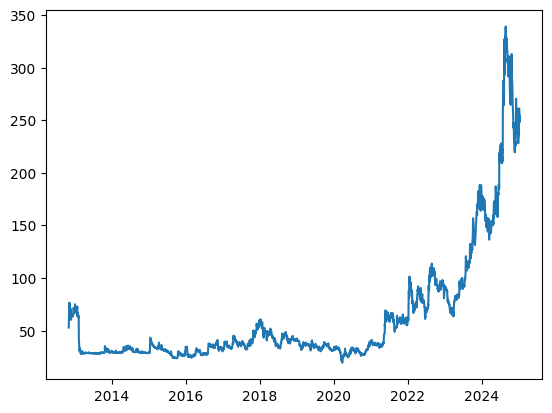

In [75]:
plt.plot(tickHistory.index, tickHistory["Close"])

In [76]:
stock_data.tail()

Price,Adj Close,Close,High,Low,Open,Volume,SMA_50,SMA_200,EMA_50,RSI,MACD,Histogram,Signal,Position,Buy_Signal_RSI,Sell_Signal_RSI,Date_Num,Daily_Return
Ticker,20MICRONS.NS,20MICRONS.NS,20MICRONS.NS,20MICRONS.NS,20MICRONS.NS,20MICRONS.NS,,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00+00:00,236.809998,236.809998,239.449997,232.050003,235.479996,38786,NaN,NaN,248.978699,None,-4.414341,-0.307818,0,0.0,0,0,1735689600000000000,0.005648
2025-01-02 00:00:00+00:00,248.649994,248.649994,248.649994,236.119995,239.399994,82081,NaN,NaN,248.965808,None,-3.148920,0.766083,0,0.0,0,0,1735776000000000000,0.049998
2025-01-03 00:00:00+00:00,261.029999,261.029999,261.079987,248.500000,255.899994,102182,NaN,NaN,249.438914,None,-1.134029,2.224779,0,0.0,0,0,1735862400000000000,0.049789
2025-01-06 00:00:00+00:00,247.970001,247.970001,263.000000,247.970001,261.000000,122720,NaN,NaN,249.381310,None,-0.584311,2.219597,0,0.0,0,0,1736121600000000000,-0.050033
2025-01-07 00:00:00+00:00,254.000000,254.000000,254.899994,239.250000,242.000000,68928,NaN,NaN,249.562435,None,0.334064,2.510378,0,0.0,0,0,1736208000000000000,0.024317


In [77]:
tickHistory.tail()

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,...,Close_Ratio_50,Trend_50,Close_Ratio_60,Trend_60,Close_Ratio_200,Trend_200,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00+05:30,235.479996,239.449997,232.050003,236.809998,38786,248.649994,1,1.002816,1.0,1.015123,...,0.949227,15.0,0.933187,21.0,1.023812,84.0,1.088753,102.0,2.053920,469.0
2025-01-02 00:00:00+05:30,239.399994,248.649994,236.119995,248.649994,82081,261.029999,1,1.024389,2.0,1.047300,...,1.001835,15.0,0.980927,22.0,1.072572,85.0,1.141851,103.0,2.152618,470.0
2025-01-03 00:00:00+05:30,255.899994,261.079987,248.500000,261.029999,102182,247.970001,0,1.024290,2.0,1.071965,...,1.055583,16.0,1.030428,22.0,1.123134,86.0,1.196885,104.0,2.255407,470.0
2025-01-06 00:00:00+05:30,261.000000,263.000000,247.970001,247.970001,122720,254.000000,1,0.974342,1.0,1.008057,...,1.007040,16.0,0.980559,21.0,1.064384,86.0,1.135486,104.0,2.138646,470.0
2025-01-07 00:00:00+05:30,242.000000,254.899994,239.250000,254.000000,68928,NaN,0,1.012013,1.0,1.017253,...,1.034924,17.0,1.005401,22.0,1.087782,86.0,1.161429,104.0,2.186601,470.0


In [78]:
def convert_string_date_datetime(dates):
    return datetime.strptime(dates, "%Y-%m-%d %H:%M:%S%z")

if prevDT not in weekHolidays:
    tickHistory.loc[convert_string_date_datetime(prevDT)]

In [79]:
tickHistory.loc[convert_string_date_datetime(prevDT)]

Open                   261.000000
High                   263.000000
Low                    247.970001
Close                  247.970001
Volume              122720.000000
Tomorrow               254.000000
Target                   1.000000
Close_Ratio_2            0.974342
Trend_2                  1.000000
Close_Ratio_5            1.008057
Trend_5                  3.000000
Close_Ratio_50           1.007040
Trend_50                16.000000
Close_Ratio_60           0.980559
Trend_60                21.000000
Close_Ratio_200          1.064384
Trend_200               86.000000
Close_Ratio_250          1.135486
Trend_250              104.000000
Close_Ratio_1000         2.138646
Trend_1000             470.000000
Name: 2025-01-06 00:00:00+05:30, dtype: float64

In [90]:
newData = tickHistory.tail(1)

In [92]:
def update_close_value(new_data, curr_date):
    for key, val in new_data.items():
        predValue = 0
        if key == 'Tomorrow':
            for k, v in new_data[key].items():
                if pd.Timestamp(k).date() != pd.Timestamp(curr_date).date():
                    if new_data['Target'][k] == 0:
                        predValue = new_data['Tomorrow'][k] - ((new_data['Tomorrow'][k] * new_data['Close_Ratio_2'][k]) / 100)
                    else:
                        predValue = new_data['Tomorrow'][k] + ((new_data['Tomorrow'][k] * new_data['Close_Ratio_2'][k]) / 100)
                    # newRowsData['Tomorrow'] = predValue
                    # print(new_data['Target'][k], round(predValue, 2))
                else:
                    new_data[key][k] = predValue
                    # print(new_data[key][k], predValue)
    return new_data


def update_market_value(new_data, curr_date):
    openVal, highVal, lowVal, closeVal = 0, 0, 0, 0
    res_data = {}
    for key, val in new_data.items():
        if key == 'Open':
            for k, v in new_data[key].items():
                if pd.Timestamp(k).date() == pd.Timestamp(curr_date).date():
                    openVal = new_data[key][k]
        if key == 'High':
            for k, v in new_data[key].items():
                if pd.Timestamp(k).date() == pd.Timestamp(curr_date).date():
                    highVal = new_data[key][k]
        if key == 'Low':
            for k, v in new_data[key].items():
                if pd.Timestamp(k).date() == pd.Timestamp(curr_date).date():
                    highVal = new_data[key][k]
        if key == 'Close':
            for k, v in new_data[key].items():
                if pd.Timestamp(k).date() == pd.Timestamp(curr_date).date():
                    closeVal = new_data['Tomorrow'][k]
    # print(curr_date, openVal, highVal, lowVal, closeVal)
    res_data[curr_date] = [openVal, highVal, lowVal, closeVal]
    return res_data
    # return new_data
update_market_value(newData, currDate)

{'2025-01-07': [242.0, 239.25, 0, 256.4748283029493]}

In [82]:
newPredData = pd.DataFrame(update_close_value(newData, currDate))
newPredData

C:\Users\Admin\AppData\Local\Temp\ipykernel_7112\2305838896.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data[key][k] = predValue


,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,...,Close_Ratio_50,Trend_50,Close_Ratio_60,Trend_60,Close_Ratio_200,Trend_200,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00+05:30,235.479996,239.449997,232.050003,236.809998,38786,248.649994,1,1.002816,1.0,1.015123,...,0.949227,15.0,0.933187,21.0,1.023812,84.0,1.088753,102.0,2.053920,469.0
2025-01-02 00:00:00+05:30,239.399994,248.649994,236.119995,248.649994,82081,261.029999,1,1.024389,2.0,1.047300,...,1.001835,15.0,0.980927,22.0,1.072572,85.0,1.141851,103.0,2.152618,470.0
2025-01-03 00:00:00+05:30,255.899994,261.079987,248.500000,261.029999,102182,247.970001,0,1.024290,2.0,1.071965,...,1.055583,16.0,1.030428,22.0,1.123134,86.0,1.196885,104.0,2.255407,470.0
2025-01-06 00:00:00+05:30,261.000000,263.000000,247.970001,247.970001,122720,254.000000,1,0.974342,1.0,1.008057,...,1.007040,16.0,0.980559,21.0,1.064384,86.0,1.135486,104.0,2.138646,470.0
2025-01-07 00:00:00+05:30,242.000000,254.899994,239.250000,254.000000,68928,256.474828,0,1.012013,1.0,1.017253,...,1.034924,17.0,1.005401,22.0,1.087782,86.0,1.161429,104.0,2.186601,470.0


In [83]:
tickHistory

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,...,Close_Ratio_50,Trend_50,Close_Ratio_60,Trend_60,Close_Ratio_200,Trend_200,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,,,,,
2012-10-30 00:00:00+05:30,51.768280,53.307339,51.301899,52.840958,428564,53.377293,1,1.013643,2.0,1.021825,...,0.951829,22.0,0.966545,27.0,1.234016,95.0,1.326369,116.0,2.316992,449.0
2012-10-31 00:00:00+05:30,53.167423,54.053547,52.817637,53.377293,285194,58.577442,1,1.005049,2.0,1.024436,...,0.962080,23.0,0.973946,28.0,1.242913,96.0,1.336443,116.0,2.336385,450.0
2012-11-01 00:00:00+05:30,53.633805,59.976588,53.633805,58.577442,1841120,69.047691,1,1.046449,2.0,1.095031,...,1.054213,24.0,1.064505,29.0,1.359290,96.0,1.462555,116.0,2.558737,451.0
2012-11-02 00:00:00+05:30,58.554121,69.863858,58.530801,69.047691,6974242,76.439835,1,1.082039,2.0,1.210251,...,1.236037,25.0,1.245766,30.0,1.594791,97.0,1.717427,116.0,3.008349,452.0
2012-11-05 00:00:00+05:30,69.957142,79.704501,69.957142,76.439835,8132200,74.481033,0,1.050809,2.0,1.231775,...,1.357924,25.0,1.366792,30.0,1.755800,98.0,1.892776,116.0,3.320916,452.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-01 00:00:00+05:30,235.479996,239.449997,232.050003,236.809998,38786,248.649994,1,1.002816,1.0,1.015123,...,0.949227,15.0,0.933187,21.0,1.023812,84.0,1.088753,102.0,2.053920,469.0
2025-01-02 00:00:00+05:30,239.399994,248.649994,236.119995,248.649994,82081,261.029999,1,1.024389,2.0,1.047300,...,1.001835,15.0,0.980927,22.0,1.072572,85.0,1.141851,103.0,2.152618,470.0
2025-01-03 00:00:00+05:30,255.899994,261.079987,248.500000,261.029999,102182,247.970001,0,1.024290,2.0,1.071965,...,1.055583,16.0,1.030428,22.0,1.123134,86.0,1.196885,104.0,2.255407,470.0


In [84]:
lastDictUpdRow = tickHistory.tail(1)

In [85]:
def update_last_data(lastDtUpdRow):
    lastNewDF = pd.DataFrame(lastDtUpdRow)
    lastNewRow = lastNewDF.tail(1)
    return lastNewRow.to_dict()


def insert_last_data(lastDictUpdRow, update_date):

    openVal, highVal, lowVal, closeVal = 0, 0, 0, 0
    volVal, tomoVal, targetVal = 0, 0, 0
    cR_2, cR_5, cR_60, cR_250, cR_1000 = 0, 0, 0, 0, 0
    tR_2, tR_5, tR_60, tR_250, tR_1000 = 0, 0, 0, 0, 0


    for ks, vs in lastDictUpdRow.items():
        for k, v in lastDictUpdRow[ks].items():
            openVal = lastDictUpdRow['Open'][k]
            highVal = lastDictUpdRow['High'][k]
            lowVal = lastDictUpdRow['Low'][k]
            closeVal = lastDictUpdRow['Close'][k]

            volVal = lastDictUpdRow['Volume'][k]
            tomoVal = lastDictUpdRow['Tomorrow'][k]
            targetVal = lastDictUpdRow['Target'][k]

            if targetVal == 0:
                print(lastDictUpdRow['Target'][k]*lastDictUpdRow['Close_Ratio_2'][k])
            else:
                print(lastDictUpdRow['Target'][k]*lastDictUpdRow['Close_Ratio_2'][k])
                

            cR_2 = lastDictUpdRow['Close_Ratio_2'][k]
            tR_2 = lastDictUpdRow['Trend_2'][k]

            cR_5 = lastDictUpdRow['Close_Ratio_5'][k]
            tR_5 = lastDictUpdRow['Trend_5'][k]

            cR_60 = lastDictUpdRow['Close_Ratio_60'][k]
            tR_60 = lastDictUpdRow['Trend_60'][k]

            cR_250 = lastDictUpdRow['Close_Ratio_250'][k]
            tR_250 = lastDictUpdRow['Trend_250'][k]

            cR_1000 = lastDictUpdRow['Close_Ratio_1000'][k]
            tR_1000 = lastDictUpdRow['Trend_1000'][k]

    timeStmp = pd.Timestamp((pd.Timestamp(update_date).date()).strftime('%Y-%m-%d %H:%M:%S+0530'), tz='Asia/Kolkata')
    
    return {'Open': openVal, 'High': highVal, 'Low': lowVal, 'Close': closeVal, 'Volume': volVal, 'Tomorrow': tomoVal,
                    'Target': targetVal, 'Close_Ratio_2': cR_2, 'Trend_2': tR_2, 'Close_Ratio_5': cR_5, 'Trend_5': tR_5,
                    'Close_Ratio_60': cR_60, 'Trend_60': tR_60, 'Close_Ratio_250': cR_250, 'Trend_250': tR_250, 'Close_Ratio_1000': cR_1000,
                    'Trend_1000': tR_1000}

In [86]:
# print(newData)
lastDictUpdRow

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,...,Close_Ratio_50,Trend_50,Close_Ratio_60,Trend_60,Close_Ratio_200,Trend_200,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,,,,,
2025-01-07 00:00:00+05:30,242.0,254.899994,239.25,254.0,68928,256.474828,0,1.012013,1.0,1.017253,...,1.034924,17.0,1.005401,22.0,1.087782,86.0,1.161429,104.0,2.186601,470.0


In [87]:
for idx in range(1):
    endDates = (pd.Timestamp(updateDT).date() + timedelta(days=1)).strftime('%Y-%m-%d %H:%M:%S+0530')
    if endDates not in tradeWeekHolidays:
        lastDictsUpdRow = insert_last_data(lastDictUpdRow, updateDT)
        updateDT = endDates
        newPredData.loc[endDates] = lastDictsUpdRow
        newPredData = pd.DataFrame(update_close_value(newPredData, endDates))
        lastDictUpdRow = update_last_data(newPredData)
    else:
       updateDT = (pd.Timestamp(endDates).date() + timedelta(days=1)).strftime('%Y-%m-%d %H:%M:%S+0530')
    # print(endDates)
newPredData

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


C:\Users\Admin\AppData\Local\Temp\ipykernel_7112\2305838896.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data[key][k] = predValue


,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,...,Close_Ratio_50,Trend_50,Close_Ratio_60,Trend_60,Close_Ratio_200,Trend_200,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00+05:30,235.479996,239.449997,232.050003,236.809998,38786,248.649994,1,1.002816,1.0,1.015123,...,0.949227,15.0,0.933187,21.0,1.023812,84.0,1.088753,102.0,2.053920,469.0
2025-01-02 00:00:00+05:30,239.399994,248.649994,236.119995,248.649994,82081,261.029999,1,1.024389,2.0,1.047300,...,1.001835,15.0,0.980927,22.0,1.072572,85.0,1.141851,103.0,2.152618,470.0
2025-01-03 00:00:00+05:30,255.899994,261.079987,248.500000,261.029999,102182,247.970001,0,1.024290,2.0,1.071965,...,1.055583,16.0,1.030428,22.0,1.123134,86.0,1.196885,104.0,2.255407,470.0
2025-01-06 00:00:00+05:30,261.000000,263.000000,247.970001,247.970001,122720,254.000000,1,0.974342,1.0,1.008057,...,1.007040,16.0,0.980559,21.0,1.064384,86.0,1.135486,104.0,2.138646,470.0
2025-01-07 00:00:00+05:30,242.000000,254.899994,239.250000,254.000000,68928,256.474828,0,1.012013,1.0,1.017253,...,1.034924,17.0,1.005401,22.0,1.087782,86.0,1.161429,104.0,2.186601,470.0
2025-01-08 00:00:00+0530,242.000000,254.899994,239.250000,254.000000,68928,253.879271,0,1.012013,1.0,1.017253,...,NaN,NaN,1.005401,22.0,NaN,NaN,1.161429,104.0,2.186601,470.0


In [115]:
for idx in range(1):
    endDates = (pd.Timestamp(updateDT).date() + timedelta(days=1)).strftime('%Y-%m-%d %H:%M:%S+0530')
    lastDictsUpdRow = insert_last_data(lastDictUpdRow, updateDT)
    updateDT = endDates
    newPredData.loc[endDates] = lastDictsUpdRow
    newPredData = pd.DataFrame(update_close_value(newPredData, endDates))
    lastDictUpdRow = update_last_data(newPredData)
newPredData

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


C:\Users\Admin\AppData\Local\Temp\ipykernel_6152\2941996774.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data[key][k] = predValue


,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00+05:30,235.479996,239.449997,232.050003,236.809998,38786,248.649994,1,1.002816,1.0,1.015123,3.0,0.933187,21.0,1.088753,102.0,2.053920,469.0
2025-01-02 00:00:00+05:30,239.399994,248.649994,236.119995,248.649994,82081,261.029999,1,1.024389,2.0,1.047300,4.0,0.980927,22.0,1.141851,103.0,2.152618,470.0
2025-01-03 00:00:00+05:30,255.899994,261.079987,248.500000,261.029999,102182,247.970001,0,1.024290,2.0,1.071965,4.0,1.030428,22.0,1.196885,104.0,2.255407,470.0
2025-01-06 00:00:00+05:30,261.000000,263.000000,247.970001,247.970001,122720,245.699997,0,0.974342,1.0,1.008057,3.0,0.980559,21.0,1.135486,104.0,2.138646,470.0
2025-01-07 00:00:00+05:30,242.000000,250.000000,239.250000,245.699997,53457,243.306039,0,0.995402,0.0,0.990598,3.0,0.973080,21.0,1.123647,103.0,2.115300,469.0
2025-01-08 00:00:00+0530,242.000000,250.000000,239.250000,245.699997,53457,240.884166,0,0.995402,0.0,0.990598,3.0,0.973080,21.0,1.123647,103.0,2.115300,469.0
2025-01-09 00:00:00+0530,242.000000,250.000000,239.250000,245.699997,53457,238.486401,0,0.995402,0.0,0.990598,3.0,0.973080,21.0,1.123647,103.0,2.115300,469.0
2025-01-10 00:00:00+0530,242.000000,250.000000,239.250000,245.699997,53457,236.112503,0,0.995402,0.0,0.990598,3.0,0.973080,21.0,1.123647,103.0,2.115300,469.0
2025-01-11 00:00:00+0530,242.000000,250.000000,239.250000,245.699997,53457,233.762235,0,0.995402,0.0,0.990598,3.0,0.973080,21.0,1.123647,103.0,2.115300,469.0
